In [1]:
# =========================================================
# RANDOM FOREST FORECASTING FOR PADDY PRODUCTION
# WITH GRID SEARCH & COMPLETE MODEL EVALUATION
# =========================================================

# ======================
# 1. IMPORT LIBRARIES
# ======================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

# ======================
# 2. LOAD DATA
# ======================

data = pd.read_excel(r"../df.xlsx")
df = data.iloc[27:, :]
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date')
df.set_index('Date', inplace=True)

ts = df['Avg_Yield_Total']

# ======================
# 3. CREATE LAG FEATURES
# ======================

df_rf = pd.DataFrame(ts)
df_rf['lag1'] = df_rf['Avg_Yield_Total'].shift(1)
df_rf['lag2'] = df_rf['Avg_Yield_Total'].shift(2)
df_rf['lag3'] = df_rf['Avg_Yield_Total'].shift(3)
df_rf.dropna(inplace=True)

# ======================
# 4. DEFINE X AND y
# ======================

X = df_rf[['lag1', 'lag2', 'lag3']]
y = df_rf['Avg_Yield_Total']

# ======================
# 5. TRAIN / TEST SPLIT
# ======================

train_size = int(len(df_rf) * 0.8)

X_train = X.iloc[:train_size]
X_test  = X.iloc[train_size:]
y_train = y.iloc[:train_size]
y_test  = y.iloc[train_size:]

print(f"Train size : {len(X_train)}")
print(f"Test size  : {len(X_test)}")

Train size : 51
Test size  : 13


In [2]:

# ======================
# 6. GRID SEARCH
# ======================

# Parameter grid
param_grid = {
    'n_estimators'     : [100, 200, 300, 500],
    'max_depth'        : [3, 5, 7, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf' : [1, 2, 4],
    'max_features'     : ['sqrt', 'log2', None]
}

# TimeSeriesSplit — preserves temporal order (no data leakage)
tscv = TimeSeriesSplit(n_splits=5)

rf_base = RandomForestRegressor(random_state=42)

grid_search = GridSearchCV(
    estimator  = rf_base,
    param_grid = param_grid,
    cv         = tscv,
    scoring    = 'neg_mean_squared_error',
    n_jobs     = -1,          # use all CPU cores
    verbose    = 2
)

print("\nRunning Grid Search...")
grid_search.fit(X_train, y_train)

# Best parameters
print("\n===================================")
print(" GRID SEARCH RESULTS")  
print("===================================")
print(f"Best Parameters : {grid_search.best_params_}")
print(f"Best CV RMSE    : {np.sqrt(-grid_search.best_score_):.2f}")


Running Grid Search...
Fitting 5 folds for each of 540 candidates, totalling 2700 fits

 GRID SEARCH RESULTS
Best Parameters : {'max_depth': 3, 'max_features': None, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 200}
Best CV RMSE    : 301.20


In [3]:

# ======================
# 7. BEST MODEL
# ======================

best_model = grid_search.best_estimator_

# ======================
# 8. PREDICTIONS
# ======================

y_pred = best_model.predict(X_test)


In [4]:


# ======================
# 9. MODEL EVALUATION
# ======================

rmse        = np.sqrt(mean_squared_error(y_test, y_pred))
mae         = mean_absolute_error(y_test, y_pred)
mape        = np.mean(np.abs((y_test - y_pred) / y_test)) * 100
r2          = r2_score(y_test, y_pred)
correlation = np.corrcoef(y_test, y_pred)[0, 1]

print("\n===================================")
print(" RANDOM FOREST MODEL EVALUATION")
print("===================================")
print(f"RMSE        : {rmse:.2f}")
print(f"MAE         : {mae:.2f}")
print(f"MAPE        : {mape:.2f}%")
print(f"R² Score    : {r2:.4f}")
print(f"Correlation : {correlation:.4f}")


 RANDOM FOREST MODEL EVALUATION
RMSE        : 722.14
MAE         : 596.91
MAPE        : 15.30%
R² Score    : -0.3739
Correlation : -0.2055


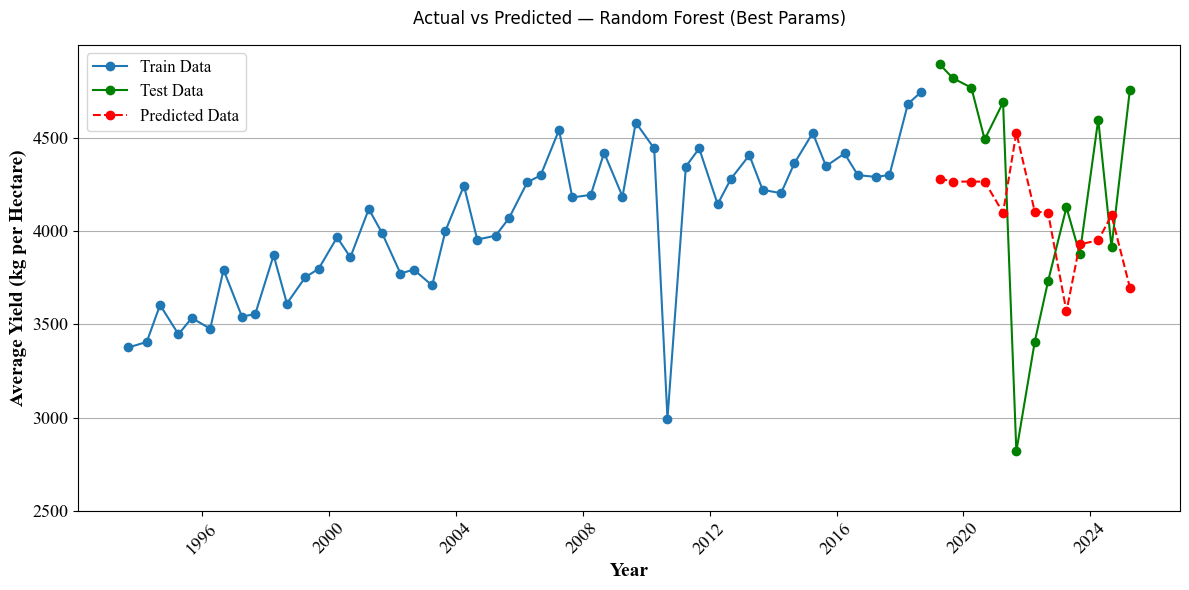

In [5]:
# ======================
# 10. ACTUAL VS PREDICTED PLOT
# ======================

plt.figure(figsize=(12, 6))

plt.plot(y_train.index, y_train,
         label='Train Data', marker='o', linewidth=1.5)

plt.plot(y_test.index, y_test,
         label='Test Data', marker='o', linewidth=1.5, color='green')

plt.plot(y_test.index, y_pred,
         label='Predicted Data', marker='o',
         linestyle='--', linewidth=1.5, color='red')

plt.xlabel("Year",       fontsize=14, fontweight='bold', fontname='Times New Roman')
plt.ylabel("Average Yield (kg per Hectare)", fontsize=14, fontweight='bold', fontname='Times New Roman')
plt.title("Actual vs Predicted — Random Forest (Best Params)", pad=15)
plt.legend(prop={'size': 12, 'family': 'Times New Roman'})
plt.grid(axis='y')
plt.xticks(rotation=45, fontsize=13, fontname='Times New Roman')
plt.yticks(fontsize=13, fontname='Times New Roman')
plt.ylim(2500,)
plt.tight_layout()
plt.show()

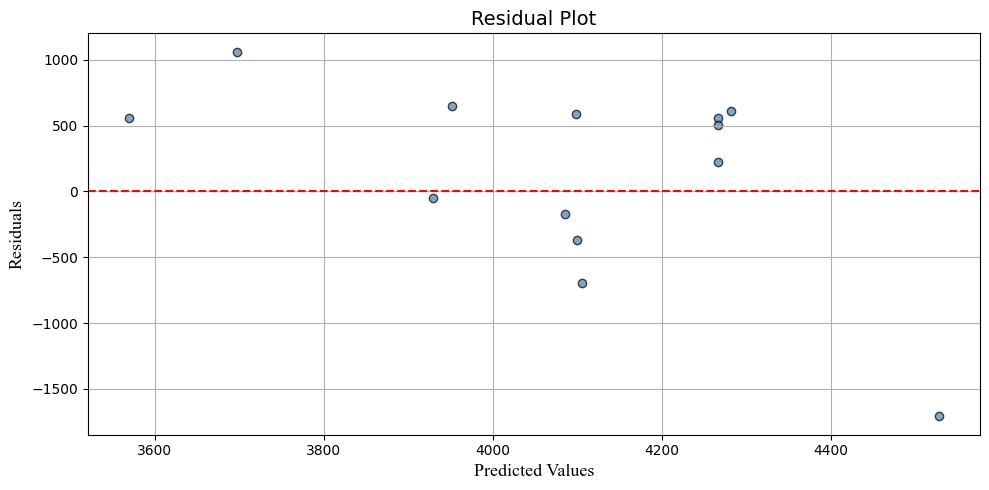

In [6]:

# ======================
# 11. RESIDUAL PLOT
# ======================

residuals = y_test - y_pred

plt.figure(figsize=(10, 5))
plt.scatter(y_pred, residuals, color='steelblue', edgecolors='k', alpha=0.7)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel("Predicted Values", fontsize=13, fontname='Times New Roman')
plt.ylabel("Residuals",        fontsize=13, fontname='Times New Roman')
plt.title("Residual Plot",     fontsize=14)
plt.grid(True)
plt.tight_layout()
plt.show()


Feature Importance:
Feature  Importance
   lag3    0.476805
   lag1    0.325772
   lag2    0.197423


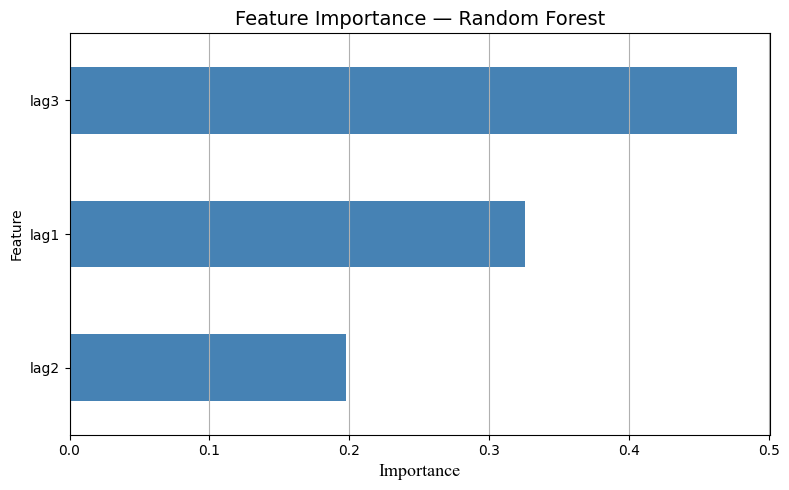

In [7]:
# ======================
# 12. FEATURE IMPORTANCE
# ======================

importance = pd.DataFrame({
    'Feature'   : X.columns,
    'Importance': best_model.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nFeature Importance:")
print(importance.to_string(index=False))

importance.sort_values('Importance').plot(
    x='Feature', y='Importance',
    kind='barh', figsize=(8, 5), legend=False, color='steelblue'
)
plt.xlabel("Importance", fontsize=13, fontname='Times New Roman')
plt.title("Feature Importance — Random Forest", fontsize=14)
plt.grid(axis='x')
plt.tight_layout()
plt.show()


In [8]:
# ======================
# 13. FUTURE FORECASTING
# (Apr ↔ Sep alternating — Yala / Maha)
# ======================

n_future   = 6        # 2 seasons × 3 years
last_date  = ts.index[-1]

# Build future dates
future_dates = []
current = last_date

for _ in range(n_future):
    if current.month == 4:
        next_date = current.replace(month=9)
    else:
        next_date = current.replace(month=4, year=current.year + 1)
    future_dates.append(next_date)
    current = next_date

future_dates = pd.DatetimeIndex(future_dates)

# Rolling forecast using lag values
future_preds = []
last_values  = list(ts.tail(3))        # [lag3, lag2, lag1]

for _ in range(n_future):
    X_future   = np.array(last_values[-3:]).reshape(1, -1)
    next_pred  = best_model.predict(X_future)[0]
    future_preds.append(round(next_pred, 2))
    last_values.append(next_pred)


C:\Users\User\AppData\Roaming\Python\Python314\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
C:\Users\User\AppData\Roaming\Python\Python314\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
C:\Users\User\AppData\Roaming\Python\Python314\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
C:\Users\User\AppData\Roaming\Python\Python314\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
C:\Users\User\AppData\Roaming\Python\Python314\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have vali

In [9]:
# ======================
# 14. FORECAST DATAFRAME
# ======================

future_df = pd.DataFrame({
    'Prediction': future_preds
}, index=future_dates)

future_df['Season'] = np.where(future_dates.month == 4, 'Yala', 'Maha')

future_df['Year'] = np.where(
    future_dates.month == 4,
    future_dates.year,
    future_dates.year + 1
)

future_df = future_df[['Year', 'Season', 'Prediction']]

print("\n3-Year Future Forecast:")
print(future_df.to_string())


3-Year Future Forecast:
            Year Season  Prediction
2025-09-01  2026   Maha     4359.91
2026-04-01  2026   Yala     4082.50
2026-09-01  2027   Maha     4208.42
2027-04-01  2027   Yala     4413.02
2027-09-01  2028   Maha     4331.53
2028-04-01  2028   Yala     4354.81


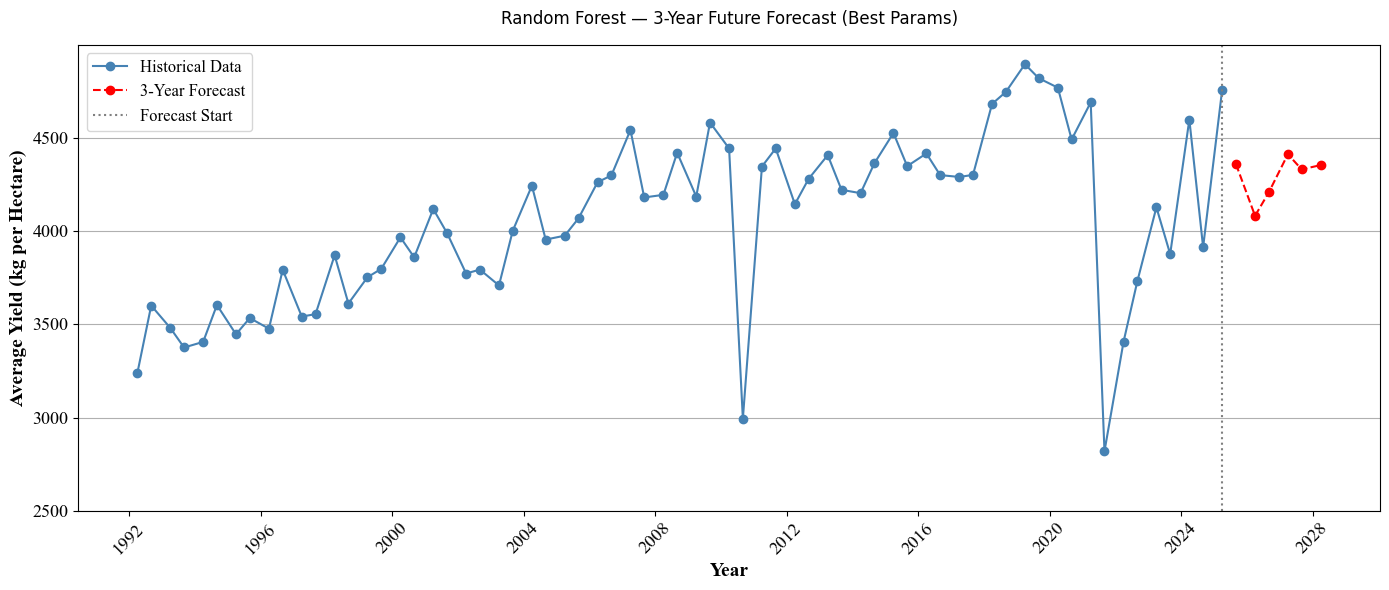

In [10]:
# ======================
# 15. PLOT FUTURE FORECAST
# ======================

plt.figure(figsize=(14, 6))

plt.plot(ts.index, ts,
         label='Historical Data', marker='o', linewidth=1.5, color='steelblue')

plt.plot(future_dates, future_preds,
         label='3-Year Forecast', marker='o',
         linestyle='--', linewidth=1.5, color='red')

plt.axvline(x=last_date, color='gray', linestyle=':',
            linewidth=1.5, label='Forecast Start')

plt.xlabel("Year",                 fontsize=14, fontweight='bold', fontname='Times New Roman')
plt.ylabel("Average Yield (kg per Hectare)", fontsize=14, fontweight='bold', fontname='Times New Roman')
plt.title("Random Forest — 3-Year Future Forecast (Best Params)", pad=15)
plt.legend(prop={'size': 12, 'family': 'Times New Roman'})
plt.grid(axis='y')
plt.xticks(rotation=45, fontsize=13, fontname='Times New Roman')
plt.yticks(fontsize=13, fontname='Times New Roman')
plt.ylim(2500,)
plt.tight_layout()
plt.show()